In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import inv_boxcox
import pandas as pd
from scipy import stats

In [2]:
def Gillespie_model(P,I0,beta,gamma, days,mu,V0):

    S=P-I0-V0
    I =I0
    R=V0
    t=0
    D=0

    t_=[]
    s_=[]
    i_=[]
    r_=[]
    d_=[]
    R0 = beta/gamma
    HT = 1-1/R0 # heard immunity threshold
    
    while t< days and I>0:
        rate_infection = S*(beta*I/P) # no. suceptible*prob. of infection
        rate_recovery = gamma * I
        death_rate = mu*I
        total_rate = rate_infection + rate_recovery + death_rate
        dt = np.random.exponential(1 / total_rate) # events have exponential distribution
        t = t+dt
        
        infection_prob = rate_infection/total_rate
        recovery_prob = rate_recovery/total_rate
        
        

        if total_rate ==0:
            break
        RN = np.random.random()
        if RN < infection_prob:
            #infection
            S =S-1  
            I =I+1
        #recovery
        elif RN < infection_prob + recovery_prob:
            I =I-1
            R =R+1
        else: #deaths
            I=I-1
            D=D+1
        t_.append(t)
        s_.append(S)
        i_.append(I)
        r_.append(R)
        d_.append(D)

    return t_,s_,i_,r_,d_
        

In [3]:
## Repeat the simulation for mutiple times 
# first define the initial values

def multi_run(P,V0,I0,beta,gamma,days,n_runs,mu):
    T_=[]
    S_=[]
    I_=[]
    R_=[]
    D_=[]
    R0 = beta/gamma
    HT = 1-1/R0 # heard immunity threshold
    np.random.seed(42)

    for i in range(0,n_runs):
        t_,s_,i_,r_,d_ = Gillespie_model(P,I0,beta,gamma, days,mu,V0)
        T_.append(t_)
        S_.append(s_)
        I_.append(i_)
        R_.append(r_)
        D_.append(d_)

    return T_,S_,I_,R_,D_
    

In [4]:


def goodness_of_fit(data, f, args): ##Kolmogorov-Smirnov test 
    ks_stat, p_value = stats.kstest(data, f, args =args)
    IsgoodFit='no'
    if p_value > 0.05:
        IsgoodFit='yes'   
    return round(ks_stat,3),round(p_value,3)

def confidence_int(data,mu, sigma,Z):
    n=len(data)
    fitted_mean = np.exp(mu + sigma**2 / 2)
    se_mu    = sigma / np.sqrt(n)
    se_sigma = sigma / np.sqrt(2 * n)
    z=Z
    lower = np.exp((mu - z * se_mu) + (sigma - z * se_sigma)**2 / 2)
    upper = np.exp((mu + z * se_mu) + (sigma + z * se_sigma)**2 / 2)
    return lower,upper


def make_dataframe(T_,S_,I_,R_, D_, P,mu,cutoff):
    min_s=[np.min(lst) for lst in S_] #not infected
    max_i=[np.max(lst) for lst in I_] #max infected
    max_index =  [np.argmax(lst) for lst in I_]
    deaths = [np.max(lst) for lst in D_]

    peak_time =[]
    for i in range(len(T_)):
        peak_time.append(T_[i][max_index[i]])
    
    df = pd.DataFrame()
    df['not_infected'] = min_s
    df['max_infected'] = max_i
    df['Recovered'] = [np.max(lst) for lst in R_]
    df['Peaktime'] = peak_time
    df['deaths'] = deaths
    df = df[df['deaths']>= P*mu/10]
    # cutoff = df['Peaktime'].sort_values()[0:15].max()
    # print(cutoff)
    df = df[df['Peaktime']>=cutoff]
    df = df.dropna()
    # print(mu*P/10)
    return df
    

def get_stat_peaktime(df):
    
    data = df['Peaktime'].dropna().values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    ax1.hist(df['Peaktime'],bins=25,label='Peak time')
    ax1.set_xlabel('Day')
    ax1.set_ylabel('Counts/Bin')
    ax1.set_title('Peak time')
    #ax1.legend()
    ax1.grid(True, alpha=0.3)
  
    tr_data, lambda_ = stats.boxcox(data)

    sns.histplot(tr_data, kde=True, ax=ax2, color='blue')
    ax2.set_title(f"Box-Cox Transformed (λ = {lambda_:.2f})")
    ax2.set_ylabel('Counts/Bin')
    plt.tight_layout()
    plt.show()
    plt.tight_layout()
    plt.show()

    #mean and CI
    mean = np.mean(tr_data)
    sigma = np.std(tr_data, ddof=1) 

    # 2. 95% CI
    lower, higher = stats.t.interval(0.95, 
                                   df=len(tr_data)-1, 
                                   loc=mean, 
                                   scale=stats.sem(tr_data))

    mean_ = inv_boxcox(mean, lambda_)
    lower_ = inv_boxcox(lower, lambda_)
    higher_ = inv_boxcox(higher, lambda_)


    # Goodness of fit
    shapiro_stat, p_value = stats.shapiro(tr_data)

    return mean_,lower_,higher_, shapiro_stat,p_value


In [5]:
def get_stat_maxInfections(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    df1 = df[df['max_infected']>20]
    data = df1['max_infected'].dropna().values
    
    ax1.hist(data,bins=25,label='')
    ax1.set_xlabel('# of people infected')
    ax1.set_ylabel('Counts/Bin')
    ax1.set_title('Infections at the peak')
    #ax1.legend()
    ax1.grid(True, alpha=0.3)
   
    tr_data, lambda_ = stats.boxcox(data)

    sns.histplot(tr_data, kde=True, ax=ax2, color='blue')
    ax2.set_title(f"Box-Cox Transformed (λ = {lambda_:.2f})")
    ax2.set_ylabel('Counts/Bin')
    plt.tight_layout()
    plt.show()
    plt.tight_layout()
    plt.show()

    #mean and CI
    mean = np.mean(tr_data)
    sigma = np.std(tr_data, ddof=1) 

    # 2. 95% CI
    lower, higher = stats.t.interval(0.95, 
                                   df=len(tr_data)-1, 
                                   loc=mean, 
                                   scale=stats.sem(tr_data))

    mean_ = inv_boxcox(mean, lambda_)
    lower_ = inv_boxcox(lower, lambda_)
    higher_ = inv_boxcox(higher, lambda_)
    plt.tight_layout()
    plt.show()

    shapiro_stat, p_value = stats.shapiro(tr_data)
    return mean_,lower_,higher_,shapiro_stat,p_value


In [6]:
def get_deaths(D_):
    deaths=[np.max(lst) for lst in D_]
    data = pd.DataFrame()
    data['deaths'] = deaths
    data = data[data['deaths']>200]
    data = data['deaths'].dropna().values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    ax1.hist(data,bins=25,label='')
    ax1.set_xlabel('# of people died')
    ax1.set_ylabel('Counts/Bin')
    ax1.set_title('# people died of Infection')
    ax1.grid(True, alpha=0.3)
    
    tr_data, lambda_ = stats.boxcox(data)

    sns.histplot(tr_data, kde=True, ax=ax2, color='blue')
    ax2.set_title(f"Box-Cox Transformed (λ = {lambda_:.2f})")
    ax2.set_ylabel('Counts/Bin')
    plt.tight_layout()
    plt.show()

    mean = np.mean(tr_data)
    sigma = np.std(tr_data, ddof=1) 

    # 2. 95% CI
    lower, higher = stats.t.interval(0.95, 
                                   df=len(tr_data)-1, 
                                   loc=mean, 
                                   scale=stats.sem(tr_data))

    mean_ = inv_boxcox(mean, lambda_)
    lower_ = inv_boxcox(lower, lambda_)
    higher_ = inv_boxcox(higher, lambda_)

    print(f"Mean Deaths: {mean_:.2f}")
    print(f"95% CI : ({lower_:.2f}, {higher_:.2f})")
    shapiro_stat, p_value = stats.shapiro(tr_data)

    print(f"Shapiro-Wilk Statistic: {shapiro_stat:.2f}")
    print(f"P-value: {p_value:.2f}")

def get_recovered(R_,V0,cutoff):
    recovered=[np.max(lst) for lst in R_]
    data = pd.DataFrame()
    data['recovered'] = recovered 
    data['recovered'] = data['recovered']-V0 #subtract vaccinations
    data = data[data['recovered']>cutoff]
    data = data['recovered'].dropna().values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    ax1.hist(data,bins=25,label='')
    ax1.set_xlabel('# of people recovered')
    ax1.set_ylabel('Counts/Bin')
    ax1.set_title('# people Recovered')
    ax1.grid(True, alpha=0.3)
    
    tr_data, lambda_ = stats.boxcox(data)

    sns.histplot(tr_data, kde=True, ax=ax2, color='blue')
    ax2.set_title(f"Box-Cox Transformed (λ = {lambda_:.2f})")
    ax2.set_ylabel('Counts/Bin')
    plt.tight_layout()
    plt.show()

    mean = np.mean(tr_data)
    sigma = np.std(tr_data, ddof=1) 
        # 2. 95% CI
    lower, higher = stats.t.interval(0.95, 
                                   df=len(tr_data)-1, 
                                   loc=mean, 
                                   scale=stats.sem(tr_data))

    mean_ = inv_boxcox(mean, lambda_)
    lower_ = inv_boxcox(lower, lambda_)
    higher_ = inv_boxcox(higher, lambda_)

    print(f"Mean- Recovered : {mean_:.2f}")
    print(f"95% CI : ({lower_:.2f}, {higher_:.2f})")
    shapiro_stat, p_value = stats.shapiro(tr_data)

    print(f"Shapiro-Wilk Statistic: {shapiro_stat:.2f}")
    print(f"P-value: {p_value:.2f}")

    

### 1.0 Simulation - with no Intervention
#### Total population: 100,000
#### Initial infections : 10
#### vaccinations: 0
#### death rate =0

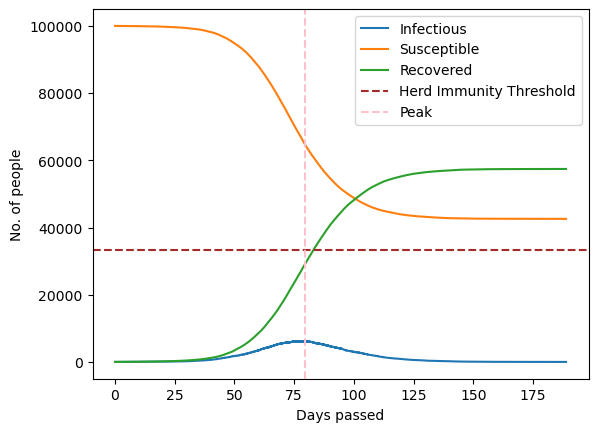

In [7]:
P = 100000 # total population
V0 =0 # vaccinated
I0 = 10 # infected
beta =0.3
gamma =0.2
days =200
mu =0.0 # death rate
#Gillespie_model(P,I0,beta,gamma, days,mu,V0)
np.random.seed(42)
a,b,c,d,e =Gillespie_model(100000,10,0.3,0.2, 200,0,V0=0)
R0 = beta/(gamma+mu)
HT = (1-1/R0)*P # heard immunity threshold
plt.plot(a,c,label='Infectious')
plt.plot(a,b,label='Susceptible')
plt.plot(a,d,label='Recovered')

plt.axhline(y=HT, color='brown', linestyle='--',label='Herd Immunity Threshold')
peak =a[np.argmax(c)]
plt.axvline(x=peak, color='pink', linestyle='--',label='Peak')
plt.xlabel("Days passed")
plt.ylabel("No. of people")
plt.legend()
plt.show()

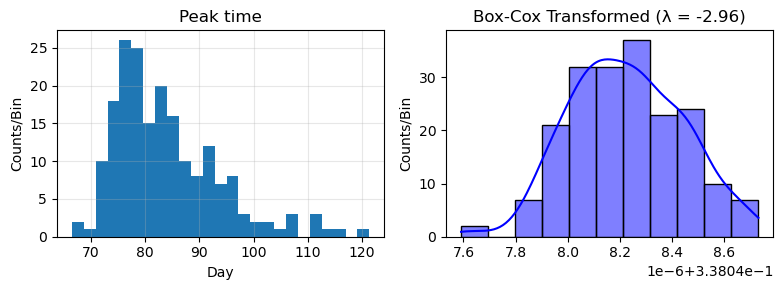

<Figure size 640x480 with 0 Axes>

Mean days to peak of the pandemic : 81.97
95% confidence interval for the mean : [80.87,83.14]
Goodness of fit results (Shapiro-Wilk) : shapiro_stat=0.99, p_value=0.34


In [8]:
## Peak time
T_,S_,I_,R_,D_ =multi_run(100000,0,I0=10,beta=0.3,gamma=0.2,days=200,n_runs=200, mu=0)
df = make_dataframe(T_,S_,I_,R_, D_, 100000,0,cutoff=50)
mean,lower_,higher_, shapiro_stat,p_value = get_stat_peaktime(df)

print(f'Mean days to peak of the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower_:.2f},{higher_:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : shapiro_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

In [9]:
# df['Peaktime'].sort_values()[0:10]

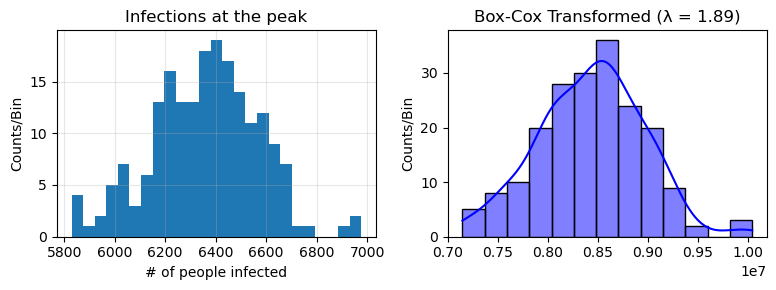

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Mean of maximun infections during the pandemic : 6361.34
95% confidence interval for the mean : [6331.53,6391.03]
Goodness of fit results (Shapiro-Wilk) : k_stat=0.99, p_value=0.34


In [10]:
##No of infections at the peak
mean,lower,upper,shapiro_stat,p_value = get_stat_maxInfections(df)
print(f'Mean of maximun infections during the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower:.2f},{upper:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : k_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

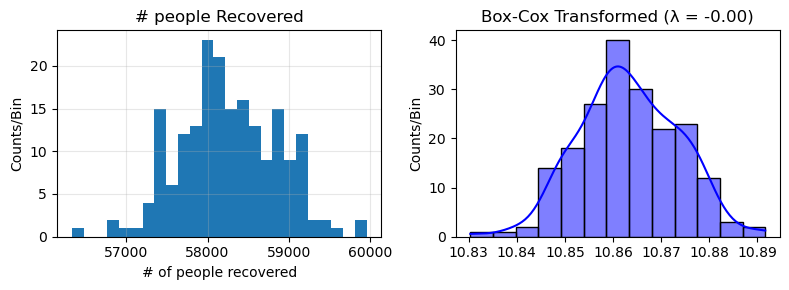

Mean- Recovered : 58251.47
95% CI : (58165.52, 58337.54)
Shapiro-Wilk Statistic: 0.99
P-value: 0.60


In [11]:
### no. of recovered (same as # gor sick in this case)
get_recovered(R_,0,18000)

### 1.1 Simuation with deaths
#### death rate = 0.01

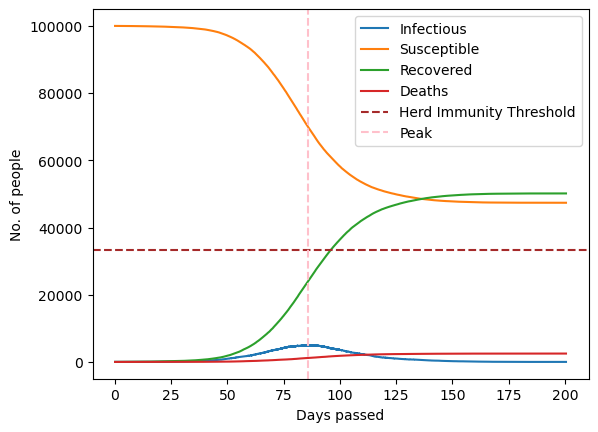

In [12]:
np.random.seed(42)
#Gillespie_model(P,I0,beta,gamma, days,mu,V0)
a,b,c,d,e =Gillespie_model(100000,10,0.3,0.2, 200,0.01,V0=0)
R0 = beta/(gamma+mu)
HT = (1-1/R0)*P # heard immunity threshold
plt.plot(a,c,label='Infectious')
plt.plot(a,b,label='Susceptible')
plt.plot(a,d,label='Recovered')
plt.plot(a,e,label='Deaths')
plt.axhline(y=HT, color='brown', linestyle='--',label='Herd Immunity Threshold')
peak =a[np.argmax(c)]
plt.axvline(x=peak, color='pink', linestyle='--',label='Peak')
plt.xlabel("Days passed")
plt.ylabel("No. of people")
plt.legend()
plt.show()

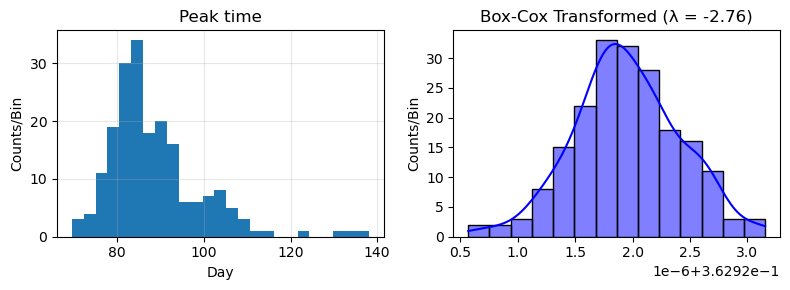

<Figure size 640x480 with 0 Axes>

Mean days to peak of the pandemic : 86.61
95% confidence interval for the mean : [85.41,87.87]
Goodness of fit results (Shapiro-Wilk) : shapiro_stat=0.99, p_value=0.64


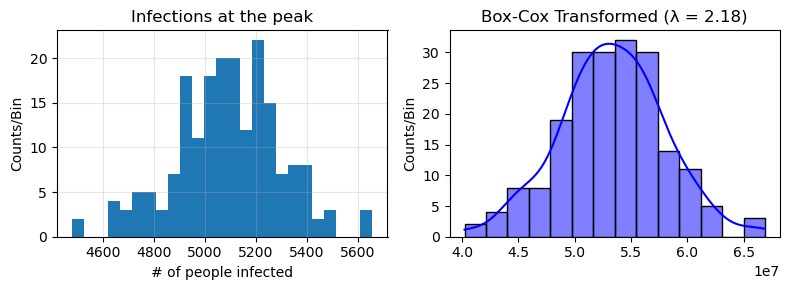

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Mean of maximun infections during the pandemic : 5097.09
95% confidence interval for the mean : [5068.12,5125.87]
Goodness of fit results (Shapiro-Wilk) : k_stat=1.00, p_value=0.82


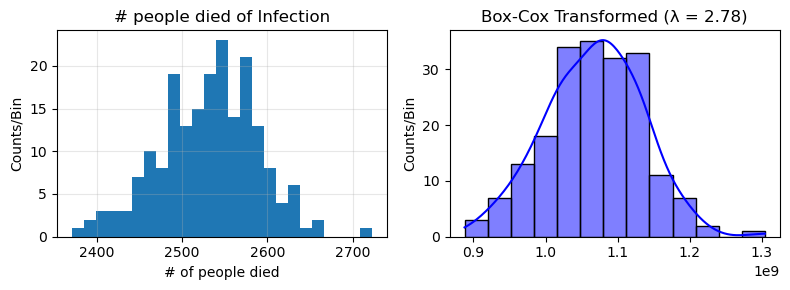

Mean Deaths: 2533.32
95% CI : (2525.18, 2541.41)
Shapiro-Wilk Statistic: 0.99
P-value: 0.74


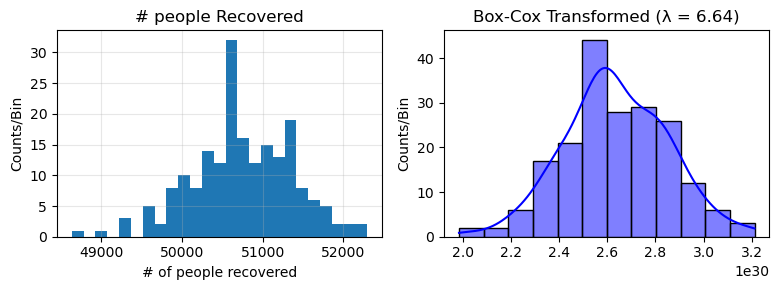

Mean- Recovered : 50763.21
95% CI : (50675.12, 50850.44)
Shapiro-Wilk Statistic: 1.00
P-value: 0.88


In [13]:
## no intervention but 0.01 death rate
T_,S_,I_,R_,D_ =multi_run(100000,0,I0=10,beta=0.3,gamma=0.2,days=200,n_runs=200, mu=0.01)
df = make_dataframe(T_,S_,I_,R_, D_, 100000,0.01,cutoff=0)
mean,lower_,higher_, shapiro_stat,p_value = get_stat_peaktime(df)

print(f'Mean days to peak of the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower_:.2f},{higher_:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : shapiro_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

mean,lower,upper,shapiro_stat,p_value = get_stat_maxInfections(df)
print(f'Mean of maximun infections during the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower:.2f},{upper:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : k_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

get_deaths(D_)

get_recovered(R_,0,18000)

### 2 Simuation with deaths + vaccinations
#### death rate = 0.01
#### vaccinations : 10%
### V0=P*0.1


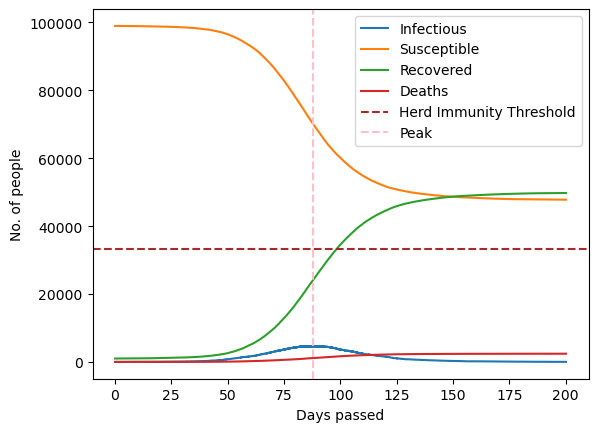

In [14]:
np.random.seed(42)
V0 = P*0.1
a,b,c,d,e =Gillespie_model(100000,10,0.3,0.2, 200,0.01,V0=P*0.01)
R0 = beta/(gamma+mu)
HT = (1-1/R0)*P # heard immunity threshold
plt.plot(a,c,label='Infectious')
plt.plot(a,b,label='Susceptible')
plt.plot(a,d,label='Recovered')
plt.plot(a,e,label='Deaths')
plt.axhline(y=HT, color='brown', linestyle='--',label='Herd Immunity Threshold')
peak =a[np.argmax(c)]
plt.axvline(x=peak, color='pink', linestyle='--',label='Peak')
plt.xlabel("Days passed")
plt.ylabel("No. of people")
plt.legend()
plt.show()

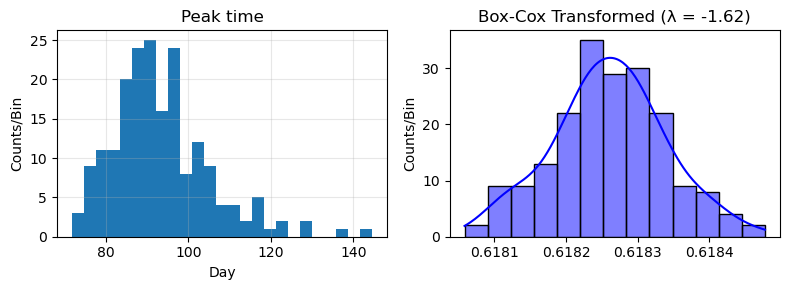

<Figure size 640x480 with 0 Axes>

Mean days to peak of the pandemic : 91.62
95% confidence interval for the mean : [90.13,93.17]
Goodness of fit results (Shapiro-Wilk) : shapiro_stat=1.00, p_value=0.82


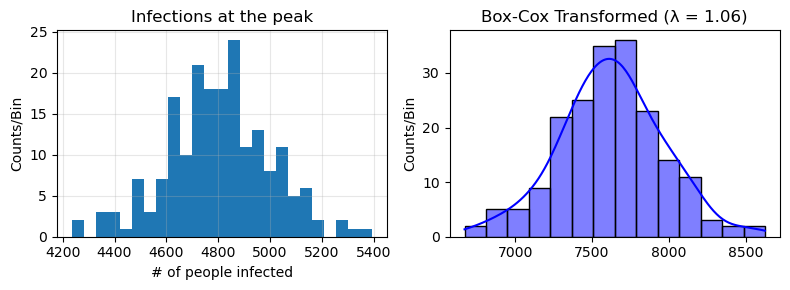

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Mean of maximun infections during the pandemic : 4804.40
95% confidence interval for the mean : [4775.83,4832.97]
Goodness of fit results (Shapiro-Wilk) : k_stat=1.00, p_value=0.83


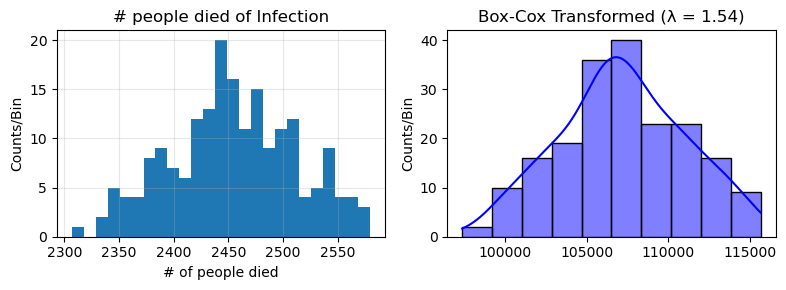

Mean Deaths: 2455.30
95% CI : (2447.13, 2463.44)
Shapiro-Wilk Statistic: 0.99
P-value: 0.26


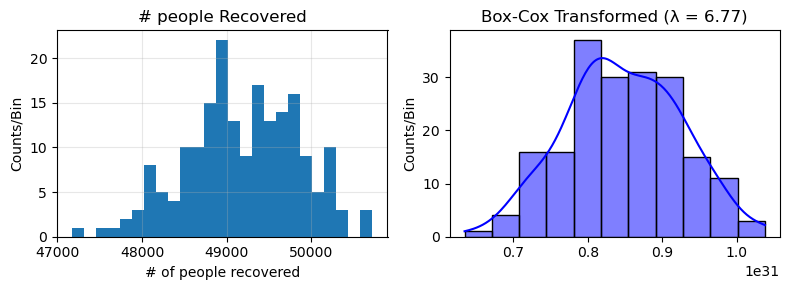

Mean- Recovered : 49221.73
95% CI : (49127.48, 49314.95)
Shapiro-Wilk Statistic: 1.00
P-value: 0.79


In [15]:
T_,S_,I_,R_,D_ =multi_run(100000,V0=P*0.01,I0=10,beta=0.3,gamma=0.2,days=200,n_runs=200, mu=0.01)

df = make_dataframe(T_,S_,I_,R_, D_, 100000,0.01,0)
mean,lower_,higher_, shapiro_stat,p_value = get_stat_peaktime(df)

print(f'Mean days to peak of the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower_:.2f},{higher_:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : shapiro_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

mean,lower,upper,shapiro_stat,p_value = get_stat_maxInfections(df)
print(f'Mean of maximun infections during the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower:.2f},{upper:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : k_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

get_deaths(D_)

get_recovered(R_,P*0.01,30000)

In [16]:
#https://pmc.ncbi.nlm.nih.gov/articles/PMC8119989/
#https://pmc.ncbi.nlm.nih.gov/articles/PMC8063609/
#https://onlinelibrary.wiley.com/doi/full/10.1002/mma.7965

### 3 Simuation with deaths + vaccinations + Social distancing
#### death rate = 0.01
#### vaccinations : 10%
### V0=P*0.1
### Social ditancing: beta=0.27

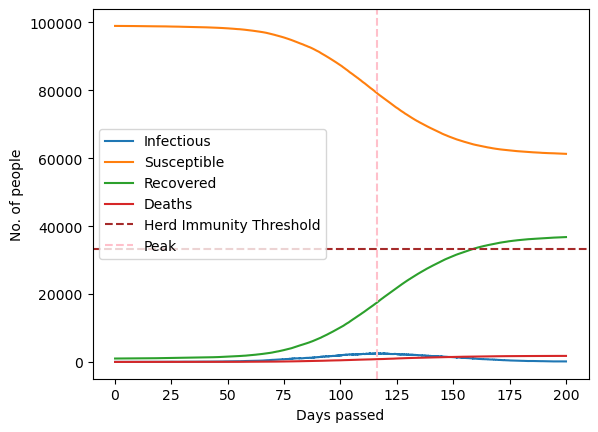

In [17]:
np.random.seed(42)
V0 = P*0.1
a,b,c,d,e =Gillespie_model(100000,10,0.27,0.2, 200,0.01,V0=P*0.01)
R0 = beta/(gamma+mu)
HT = (1-1/R0)*P # heard immunity threshold
plt.plot(a,c,label='Infectious')
plt.plot(a,b,label='Susceptible')
plt.plot(a,d,label='Recovered')
plt.plot(a,e,label='Deaths')
plt.axhline(y=HT, color='brown', linestyle='--',label='Herd Immunity Threshold')
peak =a[np.argmax(c)]
plt.axvline(x=peak, color='pink', linestyle='--',label='Peak')
plt.xlabel("Days passed")
plt.ylabel("No. of people")
plt.legend()
plt.show()

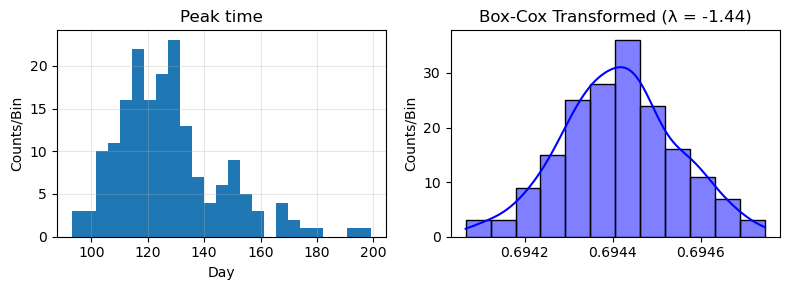

<Figure size 640x480 with 0 Axes>

Mean days to peak of the pandemic : 124.44
95% confidence interval for the mean : [122.06,126.94]
Goodness of fit results (Shapiro-Wilk) : shapiro_stat=1.00, p_value=0.88


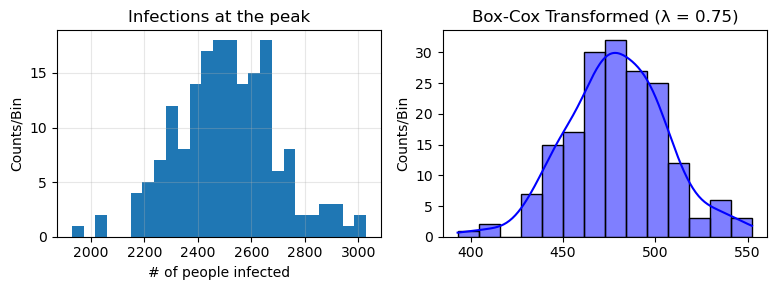

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Mean of maximun infections during the pandemic : 2508.20
95% confidence interval for the mean : [2480.63,2535.84]
Goodness of fit results (Shapiro-Wilk) : k_stat=0.99, p_value=0.70


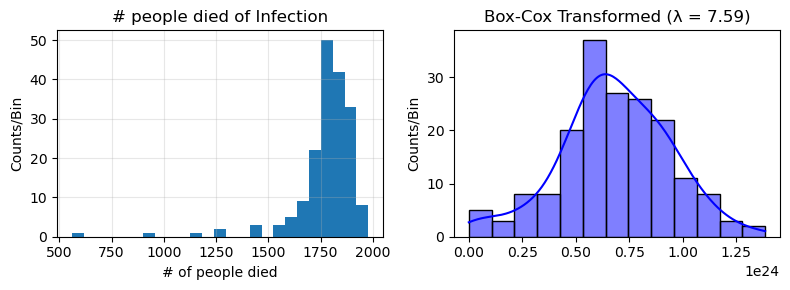

Mean Deaths: 1801.88
95% CI : (1788.36, 1814.77)
Shapiro-Wilk Statistic: 0.99
P-value: 0.24


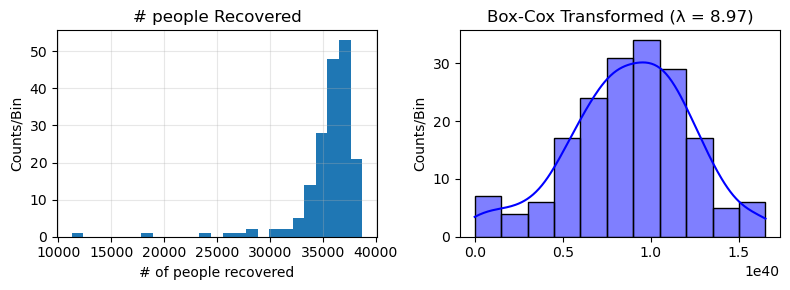

Mean- Recovered : 36104.47
95% CI : (35866.77, 36330.30)
Shapiro-Wilk Statistic: 0.99
P-value: 0.09


In [18]:
T_,S_,I_,R_,D_ =multi_run(100000,V0=P*0.01,I0=10,beta=0.27,gamma=0.2,days=200,n_runs=200, mu=0.01)

df = make_dataframe(T_,S_,I_,R_, D_, 100000,0.01,0)
mean,lower_,higher_, shapiro_stat,p_value = get_stat_peaktime(df)

print(f'Mean days to peak of the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower_:.2f},{higher_:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : shapiro_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

mean,lower,upper,shapiro_stat,p_value = get_stat_maxInfections(df)
print(f'Mean of maximun infections during the pandemic : {mean:.2f}')
print(f'95% confidence interval for the mean : [{lower:.2f},{upper:.2f}]')
print(f'Goodness of fit results (Shapiro-Wilk) : k_stat={shapiro_stat:.2f}, p_value={p_value:.2f}')

get_deaths(D_)

get_recovered(R_,P*0.01,4000)

In [19]:
# df['Recovered']
# df['Recovered']-V0